## 3.1
Consider the Yale face dataset. Apply a dimension reduction with PCA. Verify that it is possible to recognise individuals on the principal plane.

loading subject01.centerlight.pgm : (195, 231) pixels
loading subject01.glasses.pgm : (195, 231) pixels
loading subject01.happy.pgm : (195, 231) pixels
loading subject01.leftlight.pgm : (195, 231) pixels
loading subject01.noglasses.pgm : (195, 231) pixels
loading subject01.normal.pgm : (195, 231) pixels
loading subject01.rightlight.pgm : (195, 231) pixels
loading subject01.sad.pgm : (195, 231) pixels
loading subject01.sleepy.pgm : (195, 231) pixels
loading subject01.surprised.pgm : (195, 231) pixels
loading subject01.wink.pgm : (195, 231) pixels
loading subject02.centerlight.pgm : (195, 231) pixels
loading subject02.glasses.pgm : (195, 231) pixels
loading subject02.happy.pgm : (195, 231) pixels
loading subject02.leftlight.pgm : (195, 231) pixels
loading subject02.noglasses.pgm : (195, 231) pixels
loading subject02.normal.pgm : (195, 231) pixels
loading subject02.rightlight.pgm : (195, 231) pixels
loading subject02.sad.pgm : (195, 231) pixels
loading subject02.sleepy.pgm : (195, 231) pi

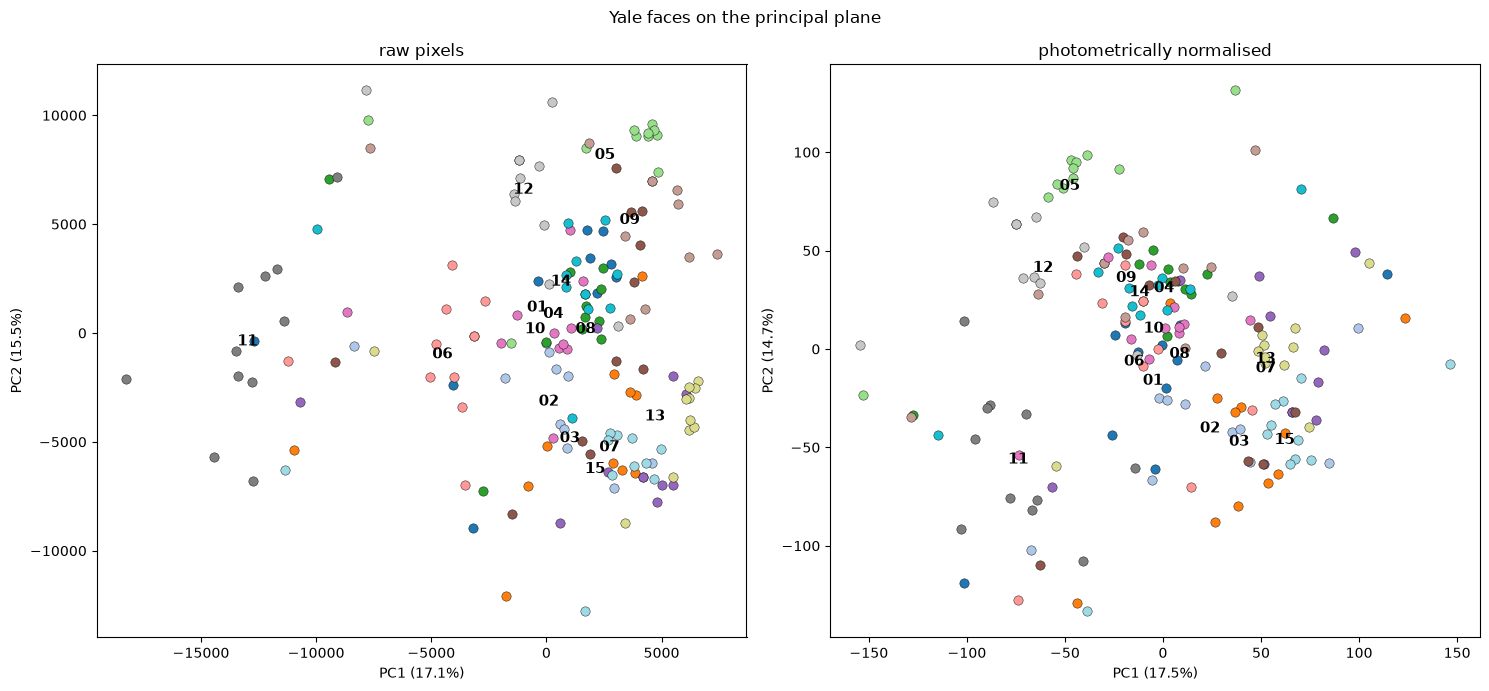

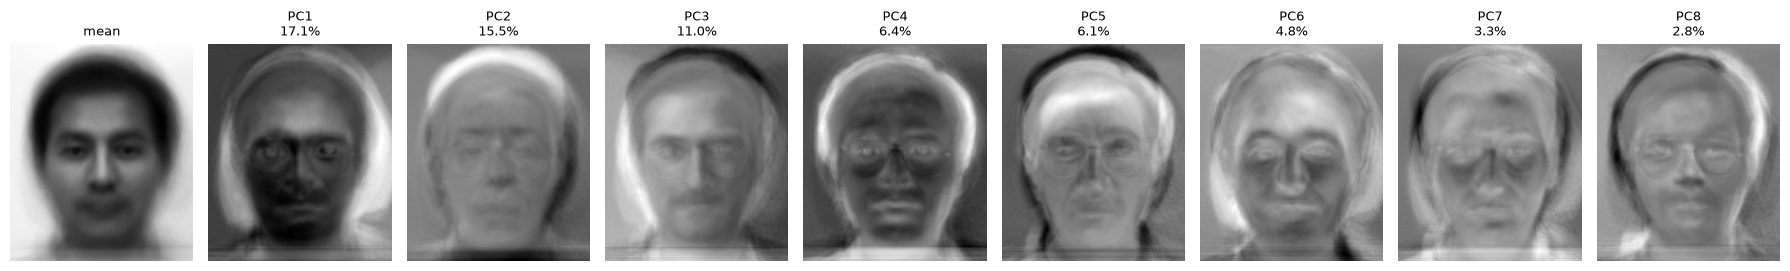

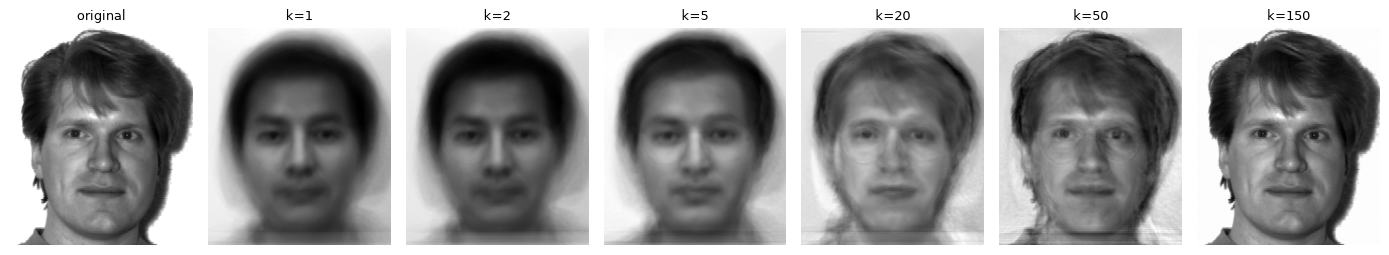

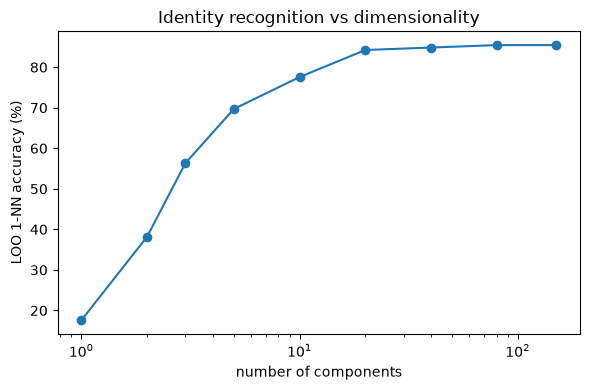

In [5]:
# %% Yale faces — PCA from scratch
import os, re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

FACES_PATH = "./YALE/centered"

# --- 1. loading ------------------------------------------------------------
def load_yale_faces(faces_path):
    images, labels, conditions = [], [], []
    for filename in sorted(os.listdir(faces_path)):
        m = re.match(r"subject(\d+)\.?(.*)", filename)
        if m is None:                      # README, .txt, hidden files
            continue
        img = Image.open(os.path.join(faces_path, filename)).convert("L")
        print(f"loading {filename} : {img.size} pixels")
        images.append(np.asarray(img, dtype=np.float64).flatten())
        labels.append(int(m.group(1)))
        conditions.append(m.group(2).replace(".gif", "") or "normal")
    return np.array(images), np.array(labels), np.array(conditions), img.size

X_raw, labels, conditions, size = load_yale_faces(FACES_PATH)
w, h = size
print(f"{X_raw.shape[0]} images, {X_raw.shape[1]} pixels each, size={size}")

# per-image standardisation: kills the global illumination factor
photo_norm = lambda X: (X - X.mean(1, keepdims=True)) / (X.std(1, keepdims=True) + 1e-8)

# --- 2. PCA via the SVD of the centred matrix ------------------------------
# p >> n (77760 pixels vs 165 images), so we never form the p x p covariance:
# X_c = U S V^T  =>  eigenvectors = rows of V^T, eigenvalues = s^2/(n-1)
class PCA:
    def fit(self, X):
        X = np.asarray(X, float); n = X.shape[0]
        self.mean_ = X.mean(0)
        U, S, Vt = np.linalg.svd(X - self.mean_, full_matrices=False)
        ev = S**2 / (n - 1)
        self.components_ = Vt
        self.explained_variance_ = ev
        self.explained_variance_ratio_ = ev / ev.sum()
        return self
    def transform(self, X):
        return (np.asarray(X, float) - self.mean_) @ self.components_.T
    def fit_transform(self, X):
        return self.fit(X).transform(X)

# --- 3. leave-one-out 1-NN, to quantify "recognisable" ---------------------
def loo_1nn(Z, y):
    sq = (Z**2).sum(1)
    D = sq[:, None] + sq[None, :] - 2 * Z @ Z.T
    np.fill_diagonal(D, np.inf)
    return (y[D.argmin(1)] == y).mean()

# --- 4. principal plane, raw vs photometrically normalised -----------------
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
results = {}
for ax, (name, X) in zip(axes, [("raw pixels", X_raw),
                                ("photometrically normalised", photo_norm(X_raw))]):
    pca = PCA().fit(X); Z = pca.transform(X); evr = pca.explained_variance_ratio_
    results[name] = (pca, Z)
    for c, s in zip(plt.cm.tab20(np.linspace(0, 1, 15)), np.unique(labels)):
        m = labels == s
        ax.scatter(Z[m, 0], Z[m, 1], color=c, s=45, edgecolor="k", linewidth=.3)
        ax.annotate(f"{s:02d}", Z[m, :2].mean(0), fontsize=11, weight="bold",
                    ha="center", va="center")
    ax.set(xlabel=f"PC1 ({evr[0]*100:.1f}%)", ylabel=f"PC2 ({evr[1]*100:.1f}%)",
           title=name)
    print(f"\n--- {name} ---")
    print("explained variance, first 5 PCs:", np.round(evr[:5]*100, 1), "%")
    print(f"components for 90% of variance : {np.searchsorted(np.cumsum(evr), .90)+1}")
    print(f"LOO 1-NN, 2 PCs (princ. plane) : {loo_1nn(Z[:, :2], labels):.1%}")
    print(f"LOO 1-NN, 20 PCs               : {loo_1nn(Z[:, :20], labels):.1%}")
    print(f"chance level                   : {1/15:.1%}")
fig.suptitle("Yale faces on the principal plane"); fig.tight_layout(); plt.show()

# --- 5. mean face + eigenfaces --------------------------------------------
pca = results["raw pixels"][0]
fig, axes = plt.subplots(1, 9, figsize=(18, 2.8))
axes[0].imshow(pca.mean_.reshape(h, w), cmap="gray"); axes[0].set_title("mean", fontsize=9)
for i, ax in enumerate(axes[1:]):
    ax.imshow(pca.components_[i].reshape(h, w), cmap="gray")
    ax.set_title(f"PC{i+1}\n{pca.explained_variance_ratio_[i]*100:.1f}%", fontsize=9)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

# --- 6. reconstruction & accuracy vs number of components ------------------
z = pca.transform(X_raw[0][None])[0]
ks = [1, 2, 5, 20, 50, 150]
fig, axes = plt.subplots(1, len(ks)+1, figsize=(2*(len(ks)+1), 2.8))
axes[0].imshow(X_raw[0].reshape(h, w), cmap="gray"); axes[0].set_title("original", fontsize=9)
for ax, k in zip(axes[1:], ks):
    ax.imshow((z[:k] @ pca.components_[:k] + pca.mean_).reshape(h, w), cmap="gray")
    ax.set_title(f"k={k}", fontsize=9)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

Zn = results["photometrically normalised"][1]
ks = [1, 2, 3, 5, 10, 20, 40, 80, 150]
plt.figure(figsize=(6, 4))
plt.plot(ks, [loo_1nn(Zn[:, :k], labels)*100 for k in ks], marker="o")
plt.xscale("log"); plt.xlabel("number of components"); plt.ylabel("LOO 1-NN accuracy (%)")
plt.title("Identity recognition vs dimensionality"); plt.tight_layout(); plt.show()